,Adj_Close,Close,High,Low,Open,Volume,log_return
Date,,,,,,,
2013-01-02,14.68,14.68,15.93,14.60,15.24,0,NaN
2013-01-03,14.56,14.56,14.92,14.24,14.77,0,-0.008208
2013-01-04,13.83,13.83,14.31,13.64,14.23,0,-0.051438
2013-01-07,13.79,13.79,14.53,13.71,14.53,0,-0.002896
2013-01-08,13.62,13.62,14.29,13.62,13.88,0,-0.012404


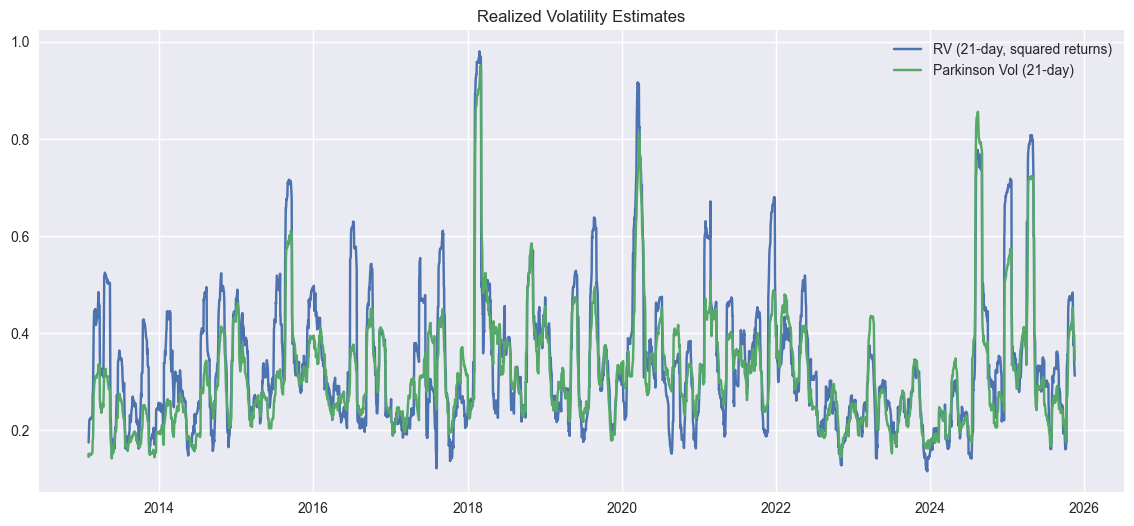

Saved realized volatility to: ../data/processed/realized_vol.csv


In [2]:
# ===========================================
# Notebook 02 — Realized Volatility
# ===========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

plt.style.use("seaborn-v0_8")

# Load  Data
DATA_PATH = "../data/raw/VIX_daily.csv"
df = pd.read_csv(DATA_PATH, parse_dates=["Date"])
df = df.sort_values("Date").set_index("Date")
display(df.head())

# Recompute log returns (avoid using Notebook 01's version)
df["log_ret"] = np.log(df["Close"]).diff()

# Squared returns-based RV (daily)
df["RV_daily_sq"] = df["log_ret"] ** 2

# Absolute return RV
df["RV_daily_abs"] = df["log_ret"].abs()

# Calculate weekly & monthly realized volatility
df["RV_5"] = np.sqrt(df["RV_daily_sq"].rolling(5).sum())      # weekly
df["RV_21"] = np.sqrt(df["RV_daily_sq"].rolling(21).sum())    # monthly

# Parkinson Daily Variance Component (σ² = (1 / (4 ln 2)) * (ln(High/Low))²)
parkinson_var = (np.log(df["High"] / df["Low"])) ** 2 / (4 * np.log(2))

# Convert variance → 21 days horizon 
df["Parkinson_21"] = np.sqrt(parkinson_var.rolling(21).sum())

# Data Visualization
plt.figure(figsize=(14, 6))
plt.plot(df["RV_21"], label="RV (21-day, squared returns)")
plt.plot(df["Parkinson_21"], label="Parkinson Vol (21-day)")
plt.title("Realized Volatility Estimates")
plt.legend()
plt.show()

# Save Final RV Data
os.makedirs("../data/processed", exist_ok=True)
OUT_PATH = "../data/processed/realized_vol.csv"
df.to_csv(OUT_PATH)
print("Saved realized volatility to:", OUT_PATH)